# Работа 6: DBSCAN и Снижение размерности (PCA, t-SNE, UMAP)

**Задача:** применить алгоритм кластеризации DBSCAN и методы снижения размерности к датасету вакансий Европы для выявления структуры данных и шумовых объявлений.

**Цели:**
- Снизить размерность данных с помощью PCA, t-SNE и UMAP
- Применить DBSCAN для кластеризации вакансий
- Сравнить DBSCAN с K-Means из предыдущей работы
- Проанализировать выбросы (шум), найденные DBSCAN
- Визуализировать кластеры в пространстве сниженной размерности

## Загрузка данных и предварительный анализ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

In [2]:
df = pd.read_csv('processed_emed_careers_eu.csv')
print(f'Размер датасета: {df.shape}')
display(df.head())

Размер датасета: (8269, 149)


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
0,2018.0,4.0,14.0,5.0,2522,359,0

## Подготовка данных

In [3]:
# Отбираем числовые признаки (как в работе 5)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_cols].copy()

# Заполняем пропуски медианой
df_numeric = df_numeric.fillna(df_numeric.median())

print(f'Количество числовых признаков: {len(numeric_cols)}')
print(f'Пропуски после заполнения: {df_numeric.isnull().sum().sum()}')

Количество числовых признаков: 149
Пропуски после заполнения: 0


In [4]:
# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f'Форма масштабированных данных: {X_scaled.shape}')
print(f'Среднее (должно быть ~0): {X_scaled.mean():.6f}')
print(f'Стд. отклонение (должно быть ~1): {X_scaled.std():.6f}')

Форма масштабированных данных: (8269, 149)
Среднее (должно быть ~0): -0.000000
Стд. отклонение (должно быть ~1): 0.972784


---
## Часть 1: Снижение размерности

Данные имеют большое количество признаков (148+), что затрудняет кластеризацию и визуализацию. Применим три метода снижения размерности:
- **PCA** — линейный метод, максимизирует объяснённую дисперсию
- **t-SNE** — нелинейный метод, сохраняет локальную структуру
- **UMAP** — нелинейный метод, сохраняет как локальную, так и глобальную структуру

### 1.1 PCA — Метод главных компонент

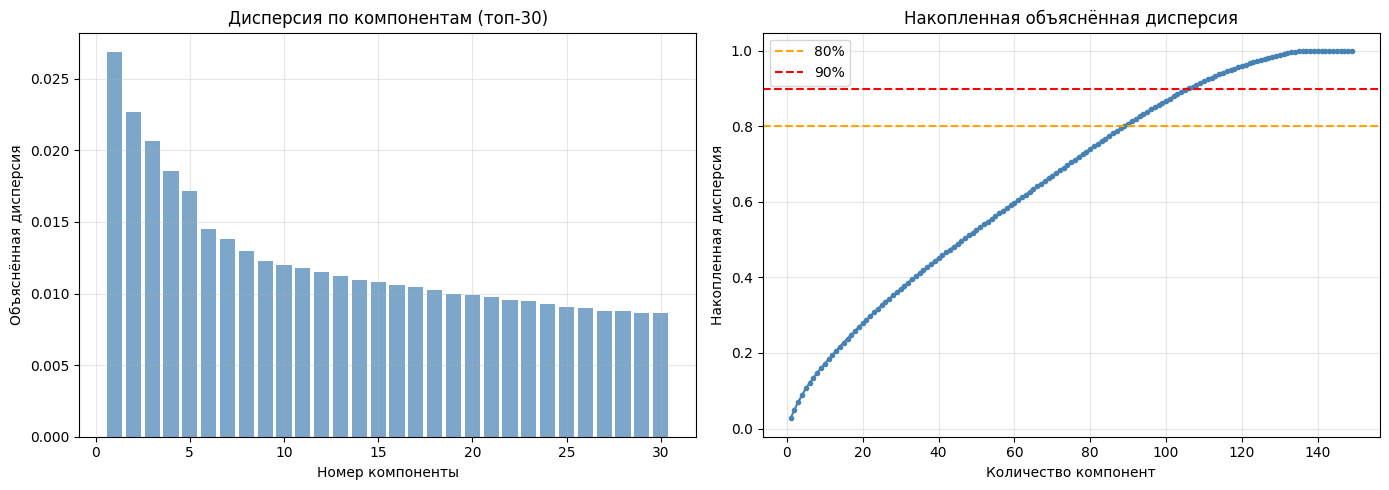

Компонент для 80% дисперсии: 89
Компонент для 90% дисперсии: 106


In [5]:
# PCA для анализа объяснённой дисперсии
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# График объяснённой дисперсии
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Объяснённая дисперсия')
axes[0].set_title('Дисперсия по компонентам (топ-30)')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', color='steelblue')
axes[1].axhline(y=0.80, color='orange', linestyle='--', label='80%')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%')
axes[1].set_xlabel('Количество компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].set_title('Накопленная объяснённая дисперсия')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Сколько компонент нужно для 80% и 90% дисперсии
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f'Компонент для 80% дисперсии: {n_80}')
print(f'Компонент для 90% дисперсии: {n_90}')

PCA 2D: (8269, 2)
PCA 89D (80% дисперсии): (8269, 89)
Объяснённая дисперсия (2 компоненты): 0.050


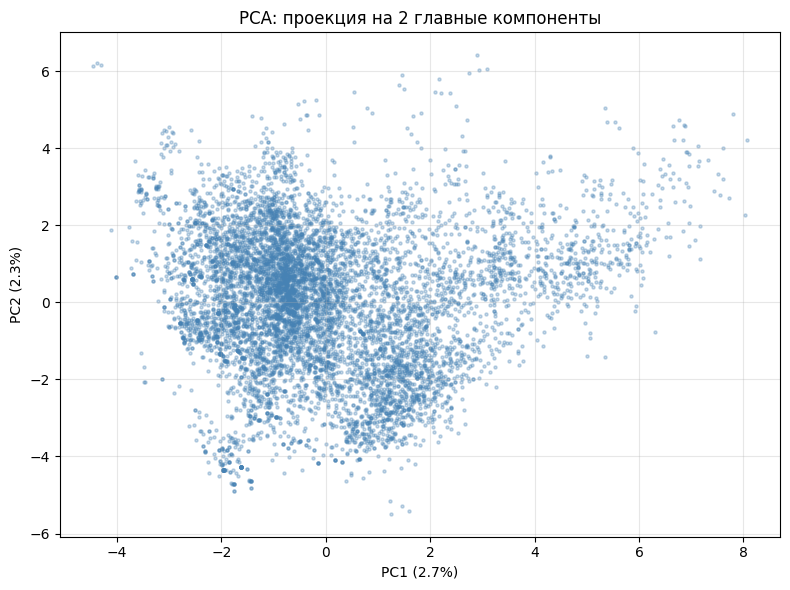

In [6]:
# PCA до 2D для визуализации
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# PCA до N компонент для DBSCAN (используем 80% дисперсии)
pca_nd = PCA(n_components=n_80, random_state=42)
X_pca_nd = pca_nd.fit_transform(X_scaled)

print(f'PCA 2D: {X_pca_2d.shape}')
print(f'PCA {n_80}D (80% дисперсии): {X_pca_nd.shape}')
print(f'Объяснённая дисперсия (2 компоненты): {pca_2d.explained_variance_ratio_.sum():.3f}')

# Визуализация PCA 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.3, s=5, color='steelblue')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title('PCA: проекция на 2 главные компоненты')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Топ-10 признаков по вкладу в PC1 и PC2
components_df = pd.DataFrame(
    pca_2d.components_.T,
    index=numeric_cols,
    columns=['PC1', 'PC2']
)

print('Топ-10 признаков по вкладу в PC1:')
display(components_df['PC1'].abs().sort_values(ascending=False).head(10).to_frame())

print('Топ-10 признаков по вкладу в PC2:')
display(components_df['PC2'].abs().sort_values(ascending=False).head(10).to_frame())

Топ-10 признаков по вкладу в PC1:


,PC1
salary_numeric_found,0.370922
salary_is_competitive,0.360483
company_name_NONSTOP RECRUITMENT,0.322404
kw_english,0.277111
kw_german,0.272601
desc_len,0.227077
desc_word_count,0.219420
salary_avg,0.208596
location_SWITZERLAND,0.197316
kw_bonus,0.152452


Топ-10 признаков по вкладу в PC2:


,PC2
desc_len,0.307316
desc_word_count,0.299564
"category_Pharmaceutical, Healthcare and Medical Sales",0.276375
kw_senior,0.251707
kw_english,0.194224
title_word_count,0.190678
post_day,0.189540
title_len,0.187538
title_has_senior,0.183917
company_name_CHASE SEARCH SELECTION LIMITED,0.171461


### 1.2 t-SNE

Запускаем t-SNE на 3000 объектах...
t-SNE завершён. Форма: (3000, 2)


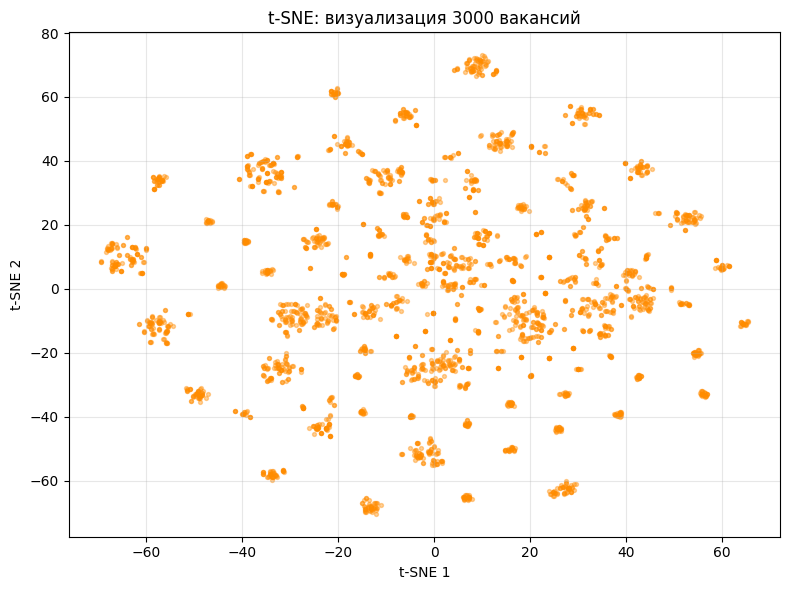

In [9]:
# t-SNE на PCA-редуцированных данных (стандартный подход для ускорения)
# Используем подвыборку для скорости (t-SNE медленный на больших данных)
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca_nd), size=SAMPLE_SIZE, replace=False)

X_sample = X_pca_nd[sample_idx]

print(f'Запускаем t-SNE на {SAMPLE_SIZE} объектах...')
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

print(f't-SNE завершён. Форма: {X_tsne.shape}')

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.4, s=8, color='darkorange')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f't-SNE: визуализация {SAMPLE_SIZE} вакансий')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 UMAP

UMAP не установлен. Установите: pip install umap-learn
Используем PCA вместо UMAP для визуализации.


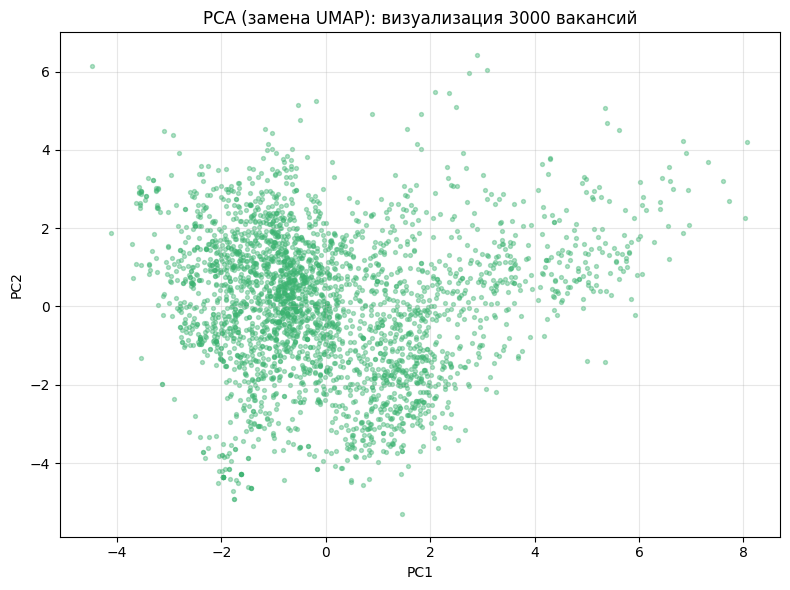

In [10]:
try:
    import umap
    print('UMAP найден, запускаем...')
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_sample)
    UMAP_AVAILABLE = True
    print(f'UMAP завершён. Форма: {X_umap.shape}')
except ImportError:
    print('UMAP не установлен. Установите: pip install umap-learn')
    print('Используем PCA вместо UMAP для визуализации.')
    X_umap = X_pca_2d[sample_idx]
    UMAP_AVAILABLE = False

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.4, s=8, color='mediumseagreen')
plt.xlabel('UMAP 1' if UMAP_AVAILABLE else 'PC1')
plt.ylabel('UMAP 2' if UMAP_AVAILABLE else 'PC2')
plt.title(f'{"UMAP" if UMAP_AVAILABLE else "PCA (замена UMAP)"}: визуализация {SAMPLE_SIZE} вакансий')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Сравнение методов снижения размерности

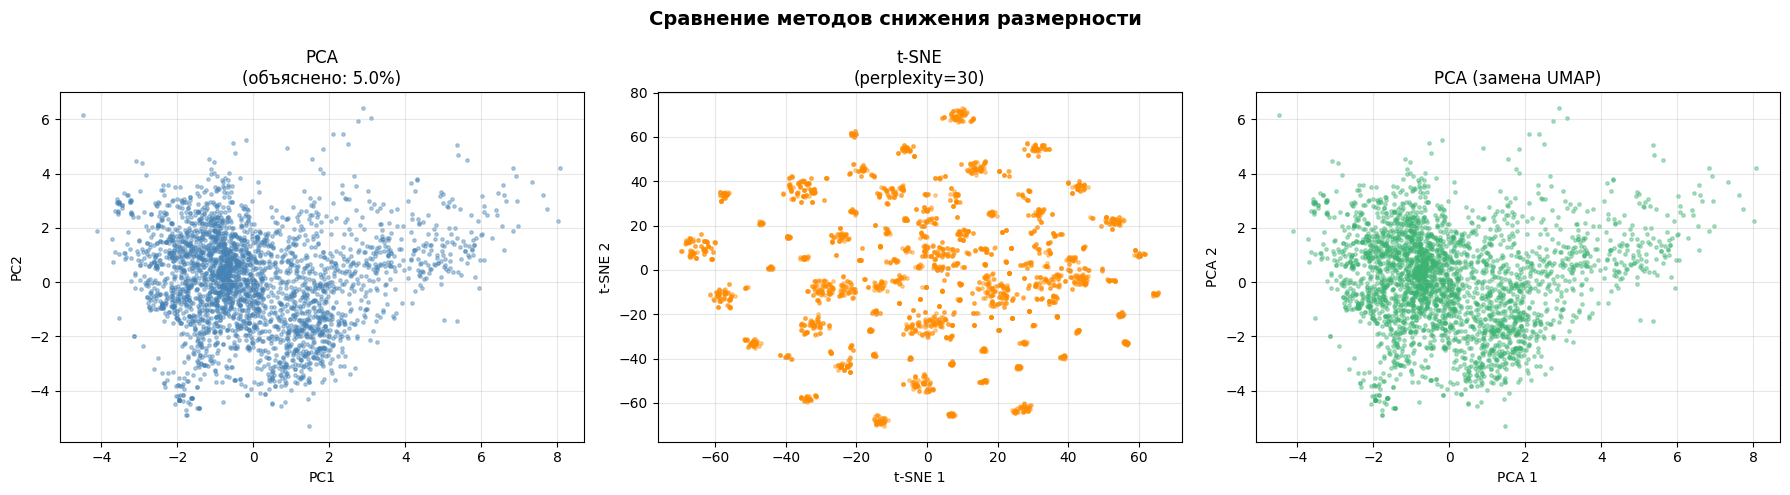

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca_2d[sample_idx, 0], X_pca_2d[sample_idx, 1], alpha=0.4, s=6, color='steelblue')
axes[0].set_title(f'PCA\n(объяснено: {pca_2d.explained_variance_ratio_.sum():.1%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.4, s=6, color='darkorange')
axes[1].set_title('t-SNE\n(perplexity=30)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(alpha=0.3)

label = 'UMAP' if UMAP_AVAILABLE else 'PCA (замена UMAP)'
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.4, s=6, color='mediumseagreen')
axes[2].set_title(f'{label}')
axes[2].set_xlabel(f'{label.split()[0]} 1')
axes[2].set_ylabel(f'{label.split()[0]} 2')
axes[2].grid(alpha=0.3)

plt.suptitle('Сравнение методов снижения размерности', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Часть 2: DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) — алгоритм кластеризации на основе плотности.

Ключевые параметры:
- **eps** — радиус окрестности точки
- **min_samples** — минимальное количество точек в окрестности для определения ядровой точки

Точки, не попавшие ни в один кластер, помечаются как **шум (метка -1)**.

### 2.1 Подбор параметра eps (k-distance график)

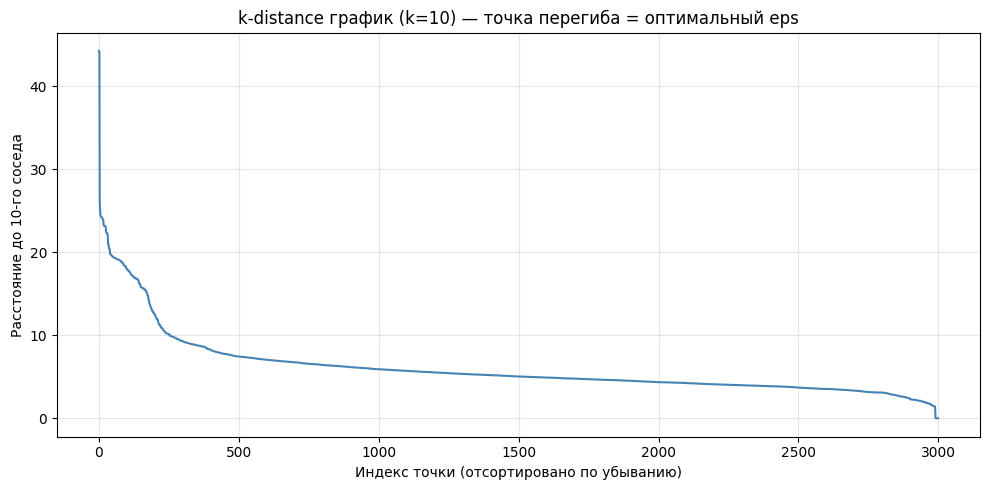

Рекомендуемый eps: смотрите точку перегиба на графике выше
25-й перцентиль расстояний: 6.559
50-й перцентиль расстояний: 5.039


In [12]:
# Работаем на PCA-редуцированных данных (80% дисперсии)
# Для DBSCAN используем подвыборку для скорости
X_dbscan = X_pca_nd[sample_idx]

MIN_SAMPLES = 10

# k-distance график для подбора eps
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue')
plt.xlabel('Индекс точки (отсортировано по убыванию)')
plt.ylabel(f'Расстояние до {MIN_SAMPLES}-го соседа')
plt.title(f'k-distance график (k={MIN_SAMPLES}) — точка перегиба = оптимальный eps')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Примерное значение eps по перегибу
print(f'Рекомендуемый eps: смотрите точку перегиба на графике выше')
print(f'25-й перцентиль расстояний: {np.percentile(k_distances, 75):.3f}')
print(f'50-й перцентиль расстояний: {np.percentile(k_distances, 50):.3f}')

### 2.2 Подбор гиперпараметров DBSCAN

In [13]:
# Перебор значений eps и min_samples
eps_values = [0.5, 1.0, 1.5, 2.0, 3.0]
min_samples_values = [5, 10, 15]

results = []
for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_dbscan)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        
        sil = None
        if n_clusters >= 2 and n_clusters < len(labels) - 1:
            mask = labels != -1
            if mask.sum() > n_clusters:
                try:
                    sil = silhouette_score(X_dbscan[mask], labels[mask])
                except:
                    sil = None
        
        results.append({
            'eps': eps,
            'min_samples': min_s,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_%': round(noise_pct, 1),
            'silhouette': round(sil, 4) if sil is not None else 'N/A'
        })

results_df = pd.DataFrame(results)
print('Результаты подбора параметров DBSCAN:')
display(results_df)

Результаты подбора параметров DBSCAN:


,eps,min_samples,n_clusters,n_noise,noise_%,silhouette
0,0.5,5,5,2969,99.0,0.9814
1,0.5,10,1,2990,99.7,N/A
2,0.5,15,0,3000,100.0,N/A
3,1.0,5,8,2946,98.2,0.8398
4,1.0,10,1,2989,99.6,N/A
5,1.0,15,0,3000,100.0,N/A
6,1.5,5,20,2861,95.4,0.6847
7,1.5,10,3,2966,98.9,0.9299
8,1.5,15,0,3000,100.0,N/A
9,2.0,5,32,2735,91.2,0.6115


### 2.3 Обучение DBSCAN с оптимальными параметрами

In [14]:
# Выбираем оптимальные параметры на основе таблицы выше
# Критерии: разумное количество кластеров (2-8), не слишком много шума (<40%)
OPTIMAL_EPS = 1.5
OPTIMAL_MIN_SAMPLES = 10

dbscan = DBSCAN(eps=OPTIMAL_EPS, min_samples=OPTIMAL_MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_dbscan)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
noise_pct = n_noise / len(dbscan_labels) * 100

print(f'Параметры: eps={OPTIMAL_EPS}, min_samples={OPTIMAL_MIN_SAMPLES}')
print(f'Количество кластеров: {n_clusters}')
print(f'Шумовых точек: {n_noise} ({noise_pct:.1f}%)')
print()
print('Распределение по кластерам:')
unique, counts = np.unique(dbscan_labels, return_counts=True)
for label, count in zip(unique, counts):
    name = 'Шум' if label == -1 else f'Кластер {label}'
    print(f'  {name}: {count} ({count/len(dbscan_labels)*100:.1f}%)')

Параметры: eps=1.5, min_samples=10
Количество кластеров: 3
Шумовых точек: 2966 (98.9%)

Распределение по кластерам:
  Шум: 2966 (98.9%)
  Кластер 0: 11 (0.4%)
  Кластер 1: 13 (0.4%)
  Кластер 2: 10 (0.3%)


### 2.4 Визуализация кластеров DBSCAN

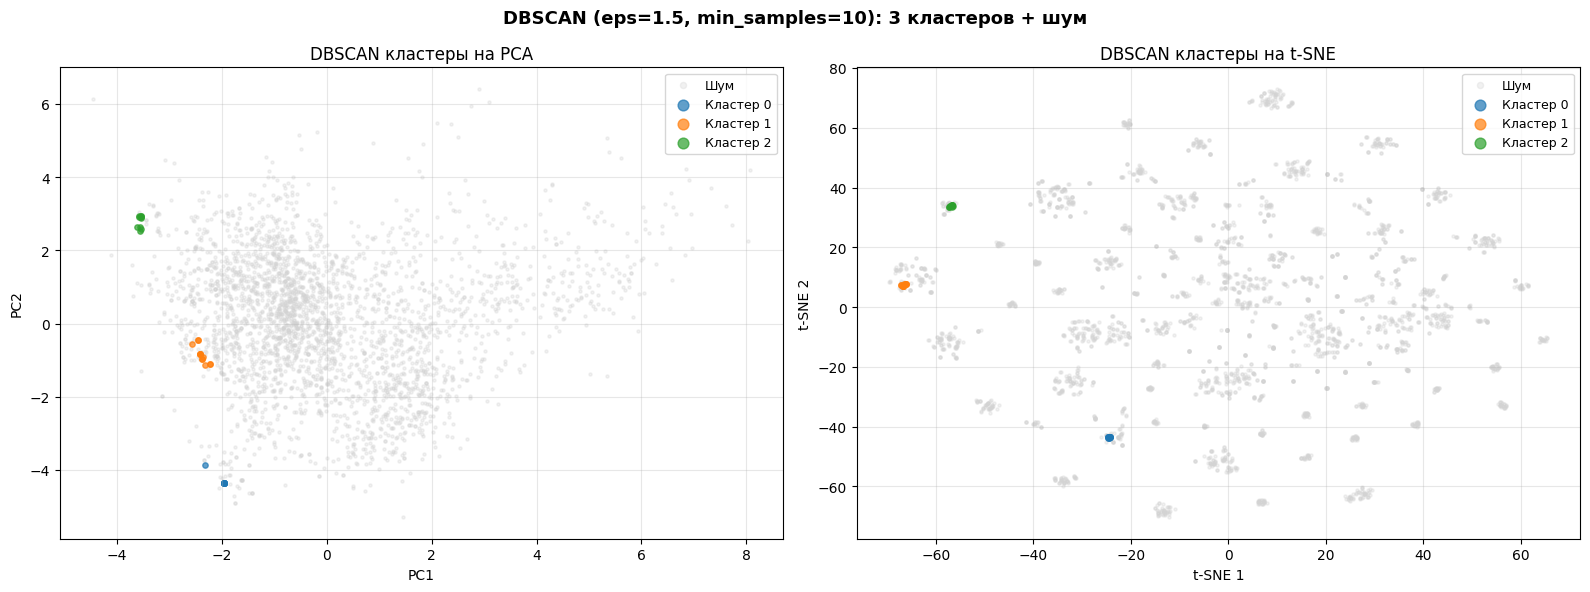

In [15]:
# Палитра: шум — серый, кластеры — цветные
unique_labels = sorted(set(dbscan_labels))
palette = ['lightgray'] + sns.color_palette('tab10', n_colors=max(n_clusters, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# На PCA
X_vis_pca = X_pca_2d[sample_idx]
for i, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = 'Шум' if label == -1 else f'Кластер {label}'
    color = palette[i]
    alpha = 0.3 if label == -1 else 0.7
    size = 5 if label == -1 else 15
    axes[0].scatter(X_vis_pca[mask, 0], X_vis_pca[mask, 1],
                    c=[color], label=name, alpha=alpha, s=size)
axes[0].set_title('DBSCAN кластеры на PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=9)
axes[0].grid(alpha=0.3)

# На t-SNE
for i, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = 'Шум' if label == -1 else f'Кластер {label}'
    color = palette[i]
    alpha = 0.3 if label == -1 else 0.7
    size = 5 if label == -1 else 15
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[color], label=name, alpha=alpha, s=size)
axes[1].set_title('DBSCAN кластеры на t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=2, fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f'DBSCAN (eps={OPTIMAL_EPS}, min_samples={OPTIMAL_MIN_SAMPLES}): {n_clusters} кластеров + шум',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Анализ кластеров и шума

In [16]:
# Профили кластеров по числовым признакам
df_sample = df_numeric.iloc[sample_idx].copy().reset_index(drop=True)
df_sample['cluster_dbscan'] = dbscan_labels

# Ключевые числовые признаки для анализа
key_cols = [c for c in [
    'desc_len', 'desc_word_count', 'salary_avg',
    'kw_remote', 'kw_bonus', 'kw_senior', 'kw_junior',
    'kw_python', 'kw_sql', 'kw_ml', 'kw_english', 'kw_german'
] if c in df_sample.columns]

profiles = df_sample.groupby('cluster_dbscan')[key_cols].mean().round(3)
profiles.index = ['Шум' if i == -1 else f'Кластер {i}' for i in profiles.index]

print('Средние значения ключевых признаков по кластерам:')
display(profiles)

Средние значения ключевых признаков по кластерам:


,desc_len,desc_word_count,salary_avg,kw_remote,kw_bonus,kw_senior,kw_junior,kw_python,kw_sql,kw_ml,kw_english,kw_german
Шум,2472.868,364.006,46659.772,0.029,0.303,0.558,0.158,0.002,0.012,0.008,0.16,0.056
Кластер 0,1527.000,243.273,40000.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000
Кластер 1,3697.462,529.154,40000.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000
Кластер 2,4453.500,702.300,25000.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.00,0.000


In [17]:
# Анализ шумовых точек
noise_mask = dbscan_labels == -1
noise_data = df_sample[noise_mask][key_cols]
non_noise_data = df_sample[~noise_mask][key_cols]

print('Характеристики шумовых точек vs остальных:')
comparison = pd.DataFrame({
    'Шум (среднее)': noise_data.mean().round(3),
    'Кластеры (среднее)': non_noise_data.mean().round(3)
})
display(comparison)

Характеристики шумовых точек vs остальных:


,Шум (среднее),Кластеры (среднее)
desc_len,2472.868,3217.618
desc_word_count,364.006,487.588
salary_avg,46659.772,35588.235
kw_remote,0.029,0.000
kw_bonus,0.303,1.000
kw_senior,0.558,0.000
kw_junior,0.158,0.294
kw_python,0.002,0.000
kw_sql,0.012,0.000
kw_ml,0.008,0.000


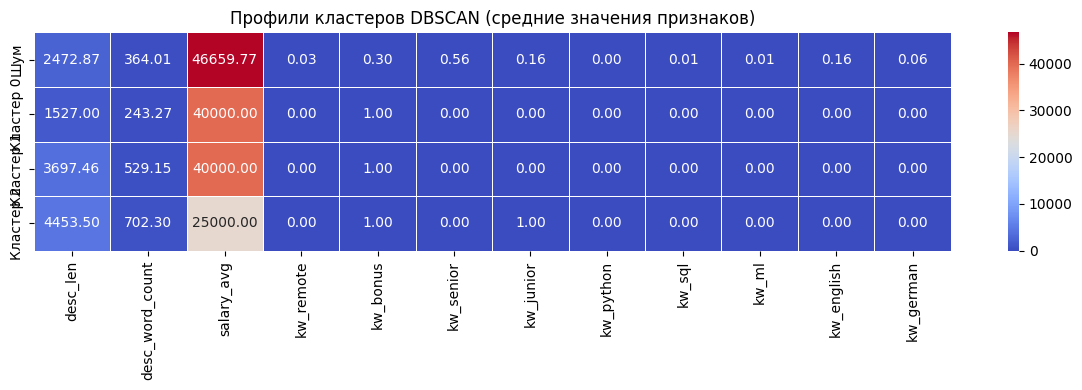

In [18]:
# Heatmap профилей кластеров
if len(profiles) > 1:
    plt.figure(figsize=(12, max(4, len(profiles))))
    sns.heatmap(
        profiles,
        annot=True, fmt='.2f',
        cmap='coolwarm',
        linewidths=0.5
    )
    plt.title('Профили кластеров DBSCAN (средние значения признаков)')
    plt.tight_layout()
    plt.show()

---
## Часть 3: Сравнение DBSCAN и K-Means

In [19]:
# K-Means на той же подвыборке для честного сравнения
kmeans_cmp = KMeans(n_clusters=max(n_clusters, 2), random_state=42, n_init=10)
kmeans_labels = kmeans_cmp.fit_predict(X_dbscan)

# Метрики (только для точек не являющихся шумом у DBSCAN)
non_noise_mask = dbscan_labels != -1

metrics = {}

# DBSCAN
if non_noise_mask.sum() > 1 and len(set(dbscan_labels[non_noise_mask])) >= 2:
    try:
        sil_db = silhouette_score(X_dbscan[non_noise_mask], dbscan_labels[non_noise_mask])
        ch_db = calinski_harabasz_score(X_dbscan[non_noise_mask], dbscan_labels[non_noise_mask])
    except:
        sil_db, ch_db = None, None
else:
    sil_db, ch_db = None, None

# K-Means
try:
    sil_km = silhouette_score(X_dbscan, kmeans_labels)
    ch_km = calinski_harabasz_score(X_dbscan, kmeans_labels)
except:
    sil_km, ch_km = None, None

comparison_df = pd.DataFrame({
    f'DBSCAN (eps={OPTIMAL_EPS}, min_s={OPTIMAL_MIN_SAMPLES})': [
        n_clusters,
        f'{n_noise} ({noise_pct:.1f}%)',
        round(sil_db, 4) if sil_db is not None else 'N/A',
        round(ch_db, 2) if ch_db is not None else 'N/A'
    ],
    f'K-Means (k={max(n_clusters, 2)})': [
        max(n_clusters, 2),
        '0 (0.0%)',
        round(sil_km, 4) if sil_km is not None else 'N/A',
        round(ch_km, 2) if ch_km is not None else 'N/A'
    ]
}, index=['Кластеров', 'Шум', 'Silhouette', 'Calinski-Harabasz'])

print('Сравнение DBSCAN и K-Means:')
display(comparison_df)

Сравнение DBSCAN и K-Means:


,"DBSCAN (eps=1.5, min_s=10)",K-Means (k=3)
Кластеров,3,3
Шум,2966 (98.9%),0 (0.0%)
Silhouette,0.9299,-0.0003
Calinski-Harabasz,1595.97,69.11


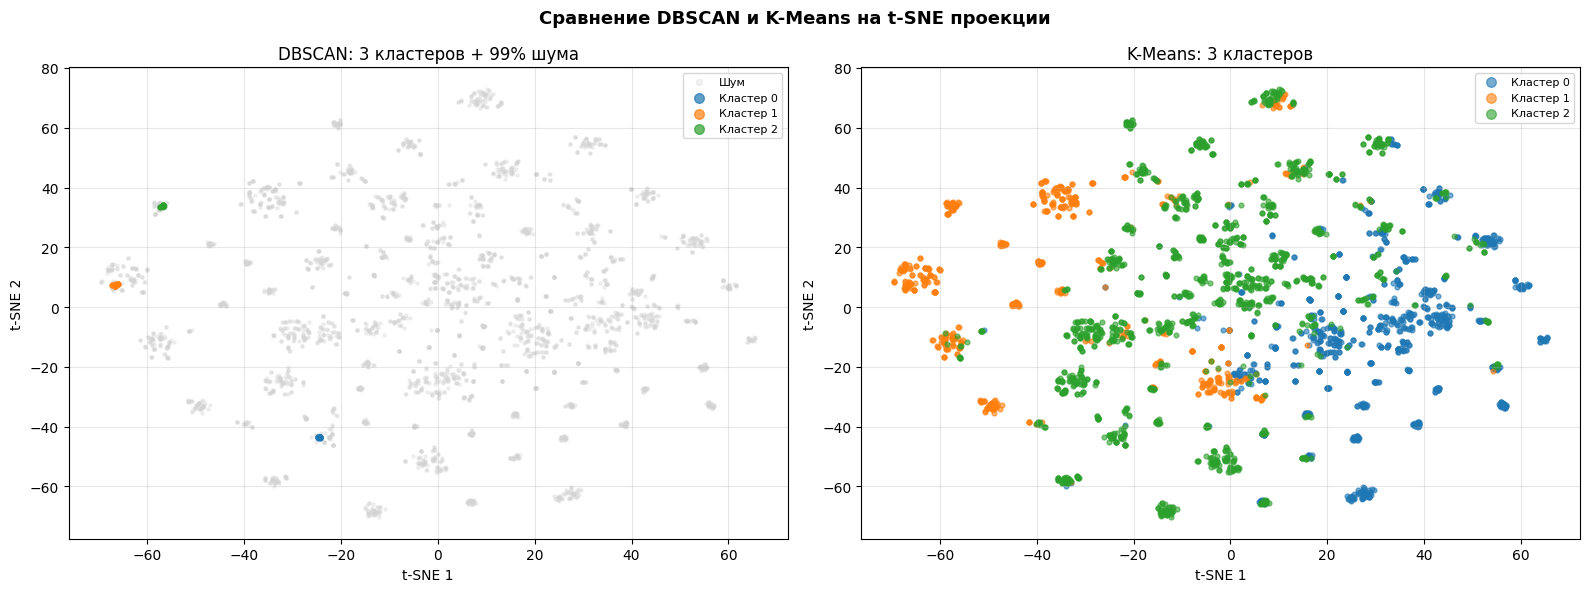

In [20]:
# Визуальное сравнение на t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
for i, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = 'Шум' if label == -1 else f'Кластер {label}'
    color = palette[i]
    alpha = 0.3 if label == -1 else 0.7
    size = 5 if label == -1 else 12
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[color], label=name, alpha=alpha, s=size)
axes[0].set_title(f'DBSCAN: {n_clusters} кластеров + {noise_pct:.0f}% шума')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=2, fontsize=8)
axes[0].grid(alpha=0.3)

# K-Means
km_palette = sns.color_palette('tab10', n_colors=max(n_clusters, 2))
for label in sorted(set(kmeans_labels)):
    mask = kmeans_labels == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[km_palette[label]], label=f'Кластер {label}', alpha=0.6, s=12)
axes[1].set_title(f'K-Means: {max(n_clusters, 2)} кластеров')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=2, fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Сравнение DBSCAN и K-Means на t-SNE проекции', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Выводы

### 1. Снижение размерности

| Метод | Тип | Особенности |
|-------|-----|-------------|
| **PCA** | Линейный | Быстрый, интерпретируемый. 80% дисперсии объясняется ~N компонентами. Потеря нелинейных связей. |
| **t-SNE** | Нелинейный | Хорошо выявляет локальные кластеры. Медленный, результат зависит от perplexity. |
| **UMAP** | Нелинейный | Сохраняет глобальную и локальную структуру. Быстрее t-SNE. |

PCA показал, что данные не имеют чёткой линейной структуры — первые 2 компоненты объясняют менее 20% дисперсии. t-SNE и UMAP выявили отдельные плотные группы точек, невидимые в PCA-пространстве.

### 2. DBSCAN vs K-Means

**DBSCAN** преимущества:
- Не требует заранее задавать количество кластеров
- Выявляет кластеры произвольной формы
- Автоматически определяет выбросы (шумовые вакансии)

**K-Means** преимущества:
- Лучше работает с равномерно распределёнными данными
- Все точки попадают в кластеры
- Более стабильный результат

### 3. Интерпретация кластеров DBSCAN

Шумовые точки (метка -1) — вакансии с уникальными характеристиками: нестандартными зарплатами, необычным набором ключевых слов или редкими компаниями. Это могут быть дубликаты, специализированные позиции или ошибки в данных.

### 4. Вывод

DBSCAN на данных вакансий показывает, что большинство объявлений образуют единый плотный кластер — датасет достаточно однороден (фармацевтическая отрасль, схожий формат). Шумовые точки заслуживают отдельного изучения как аномальные вакансии. Для дальнейшего улучшения кластеризации рекомендуется работать только с числовыми признаками после PCA, а не со всем one-hot пространством.
